In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── 1. Load ──────────────────────────────────────────────────────
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.info()
# 167 countries, 10 columns (country name + 9 numeric features)

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [4]:
# ── 2. Clean ──────────────────────────────────────────────────────
df_clean = df.drop('country', axis=1)  # drop name, keep 9 numeric features
print("Missing values:", df_clean.isnull().sum().sum())
print("Features:", df_clean.columns.tolist())

Missing values: 0
Features: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [5]:
# ── 3. Scale ──────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
print("Shape:", X_scaled.shape)  # (167, 9)

Shape: (167, 9)


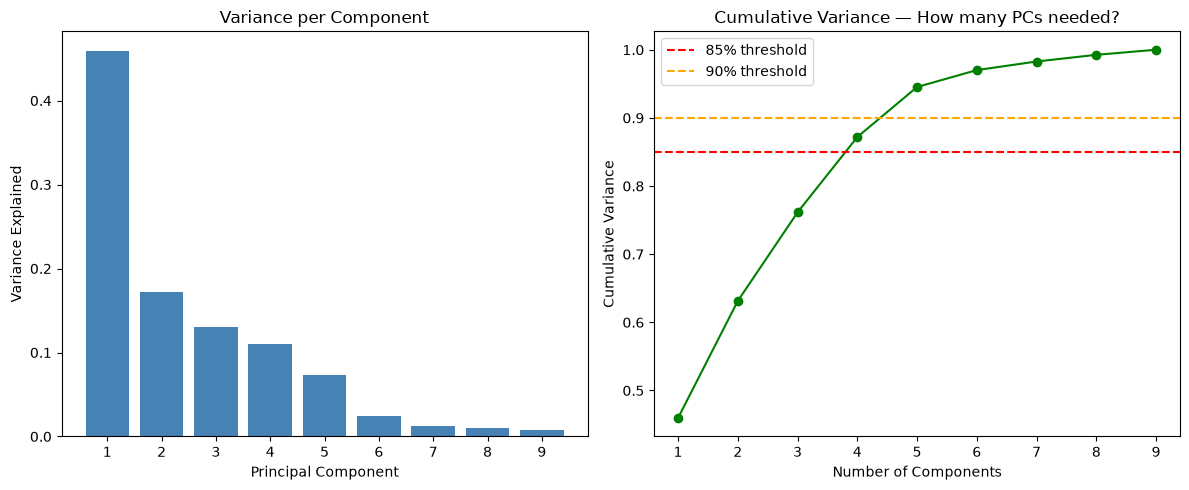

1 components: 46.0% variance retained
2 components: 63.1% variance retained
3 components: 76.1% variance retained
4 components: 87.2% variance retained
5 components: 94.5% variance retained
6 components: 97.0% variance retained
7 components: 98.3% variance retained
8 components: 99.3% variance retained
9 components: 100.0% variance retained


In [ ]:
# ── 4. Variance diagnostic — the key decision step ────────────────
# Run full PCA and check how variance distributes across components.
# For this dataset, expect 3 PCs to capture 75-85% — high enough to
# cluster in PCA space AND get an accurate 3D scatter plot.

pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(range(1, 10), pca_full.explained_variance_ratio_, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Variance per Component')
axes[0].set_xticks(range(1, 10))

axes[1].plot(range(1, 10), cumulative_variance, marker='o', color='green')
axes[1].axhline(y=0.85, color='r', linestyle='--', label='85% threshold')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Variance — How many PCs needed?')
axes[1].legend()

plt.tight_layout()
plt.show()

for i, v in enumerate(cumulative_variance, 1):
    print(f"{i} components: {v*100:.1f}% variance retained")

In [25]:
# ── 5. Apply PCA to 3 components ─────────────────────────────────
# This dataset compresses well — 3 PCs should capture ~75-85%.
# Clustering on 3 PCs means the scatter plot is a near-perfect
# picture of the actual clustering, not just an approximation.

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(f"PC1 variance: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 variance: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"PC3 variance: {pca.explained_variance_ratio_[2]*100:.1f}%")
print(f"Total retained: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"\nShape: {X_scaled.shape} → {X_pca.shape}")

PC1 variance: 46.0%
PC2 variance: 17.2%
PC3 variance: 13.0%
Total retained: 76.1%

Shape: (167, 9) → (167, 3)


PC Loadings (how much each feature contributes):
              PC1    PC2    PC3
child_mort -0.420  0.193 -0.030
exports     0.284  0.613  0.145
health      0.151 -0.243 -0.597
imports     0.161  0.672 -0.300
income      0.398  0.023  0.302
inflation  -0.193 -0.008  0.643
life_expec  0.426 -0.223  0.114
total_fer  -0.404  0.155  0.020
gdpp        0.393 -0.046  0.123


<Figure size 800x500 with 0 Axes>

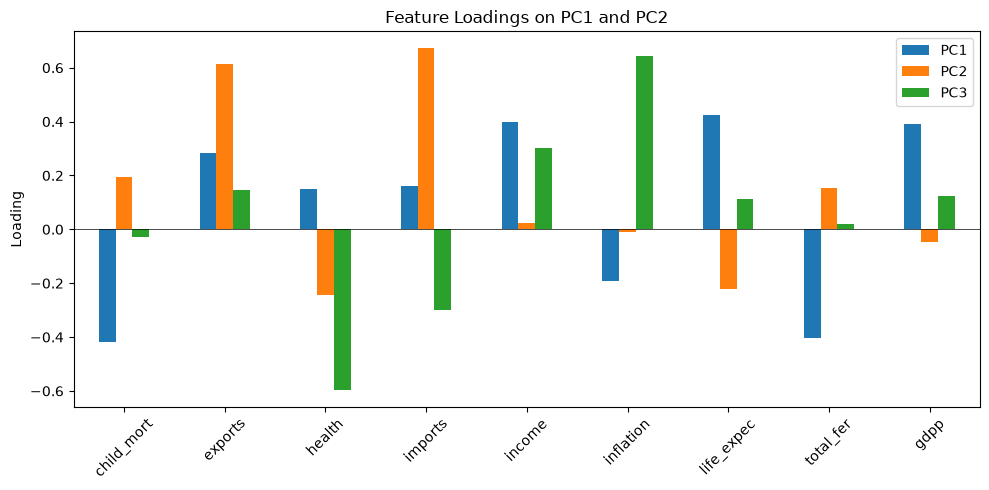

In [26]:
# ── 6. What does each PC represent? ──────────────────────────────
# Loadings show which original features drive each component
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_clean.columns,
    columns=['PC1', 'PC2', 'PC3']
)
print("PC Loadings (how much each feature contributes):")
print(loadings.round(3))

plt.figure(figsize=(8, 5))
loadings.plot(kind='bar', figsize=(10, 5))
plt.title('Feature Loadings on PC1 and PC2')
plt.ylabel('Loading')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

K=2: silhouette = 0.349
K=3: silhouette = 0.372
K=4: silhouette = 0.309
K=5: silhouette = 0.289
K=6: silhouette = 0.306
K=7: silhouette = 0.311
K=8: silhouette = 0.288
K=9: silhouette = 0.313
K=10: silhouette = 0.314


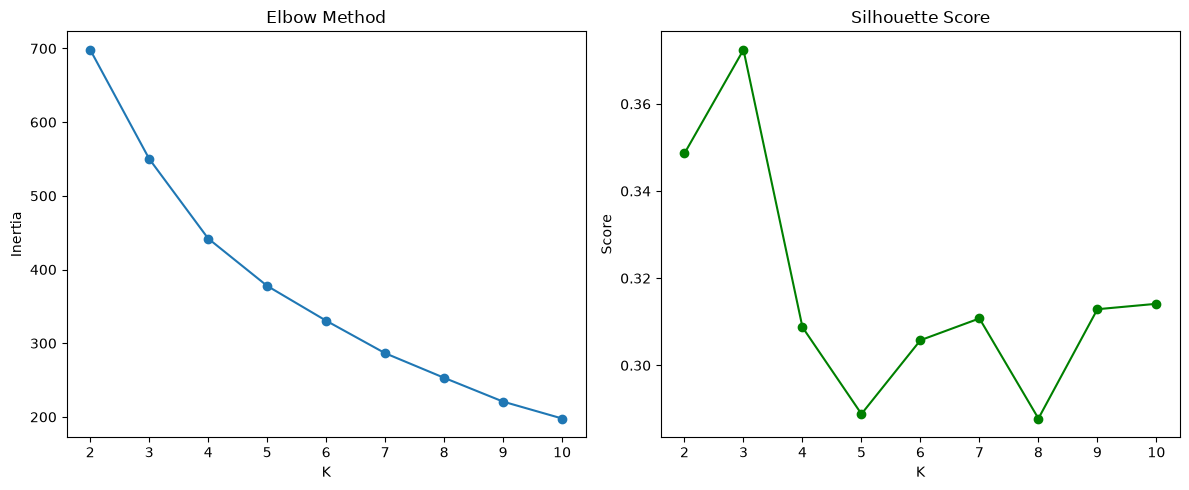


Best K: 3


In [27]:
# ── 7. Elbow + Silhouette on PCA data ────────────────────────────
inertias, sil_scores = [], []
range_k = list(range(2, 11))

for k in range_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))
    print(f"K={k}: silhouette = {sil_scores[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(range_k, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].plot(range_k, sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

best_k = range_k[np.argmax(sil_scores)]
print(f"\nBest K: {best_k}")

In [ ]:
# ── 8. Final clustering on 3 PCs ─────────────────────────────────
kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_pca)

print("Cluster sizes:")
print(df['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    70
1    94
2     3
Name: count, dtype: int64


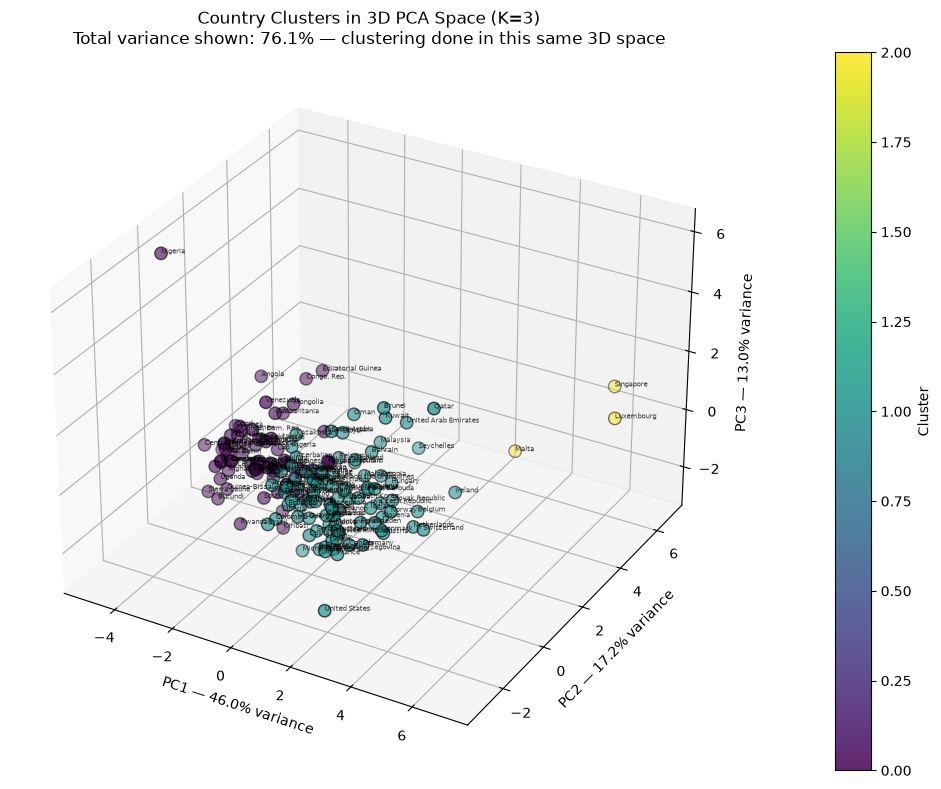

In [29]:
# ── 9. 3D Scatter plot — perfectly accurate since clustering was in 3D PCA space
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=df['Cluster'], cmap='viridis',
                     edgecolors='k', s=80, alpha=0.85)

plt.colorbar(scatter, ax=ax, label='Cluster', pad=0.1)

# Label each country
for i, row in df.iterrows():
    ax.text(X_pca[i, 0], X_pca[i, 1], X_pca[i, 2],
            row['country'], fontsize=5, alpha=0.7)

ax.set_xlabel(f"PC1 — {pca.explained_variance_ratio_[0]*100:.1f}% variance")
ax.set_ylabel(f"PC2 — {pca.explained_variance_ratio_[1]*100:.1f}% variance")
ax.set_zlabel(f"PC3 — {pca.explained_variance_ratio_[2]*100:.1f}% variance")

ax.set_title(f"Country Clusters in 3D PCA Space (K={best_k})\n"
             f"Total variance shown: {sum(pca.explained_variance_ratio_)*100:.1f}% "
             f"— clustering done in this same 3D space")

plt.tight_layout()
plt.show()

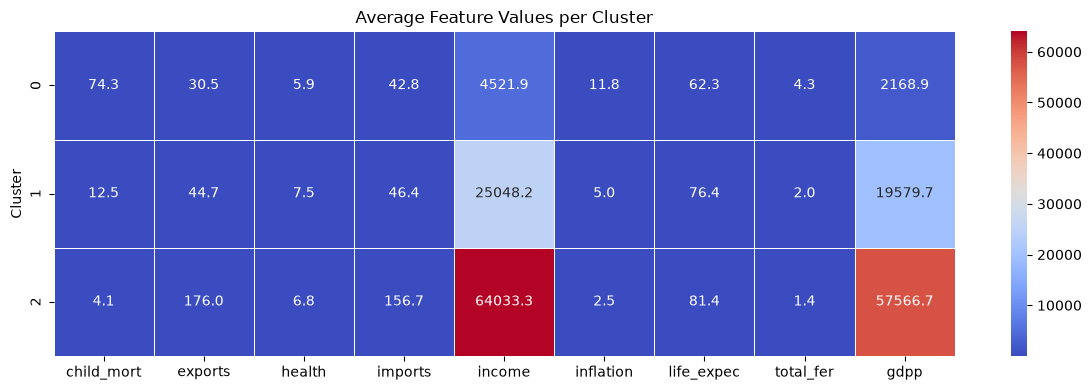


Countries per cluster:

Cluster 0 (70 countries): Afghanistan, Angola, Bangladesh, Benin, Bolivia, Botswana, Burkina Faso, Burundi, Cambodia, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Egypt, Equatorial Guinea, Eritrea, Fiji, Gabon, Gambia, Ghana, Guatemala, Guinea, Guinea-Bissau, Guyana, Haiti, India, Indonesia, Iraq, Kenya, Kiribati, Kyrgyz Republic, Lao, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mongolia, Mozambique, Myanmar, Namibia, Nepal, Niger, Nigeria, Pakistan, Philippines, Rwanda, Samoa, Senegal, Sierra Leone, Solomon Islands, South Africa, Sri Lanka, Sudan, Tajikistan, Tanzania, Timor-Leste, Togo, Tonga, Turkmenistan, Uganda, Uzbekistan, Vanuatu, Venezuela, Yemen, Zambia

Cluster 1 (94 countries): Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Australia, Austria, Azerbaijan, Bahamas, Bahrain, Barbados, Belarus, Belgium, Belize, Bhutan, Bosnia and Herzegovina, Brazil, Brunei, Bulgaria, Canada, Ca

In [30]:
# ── 10. Interpret clusters ────────────────────────────────────────
cluster_means = df.groupby('Cluster')[df_clean.columns].mean()

plt.figure(figsize=(12, 4))
sns.heatmap(cluster_means, annot=True, fmt='.1f', cmap='coolwarm', linewidths=0.5)
plt.title('Average Feature Values per Cluster')
plt.tight_layout()
plt.show()

print("\nCountries per cluster:")
for c in sorted(df['Cluster'].unique()):
    countries = df[df['Cluster'] == c]['country'].tolist()
    print(f"\nCluster {c} ({len(countries)} countries): {', '.join(countries)}")

In [32]:
# ── 11. Final scores ──────────────────────────────────────────────
final_score = silhouette_score(X_pca, df['Cluster'])
print(f"Final silhouette score: {final_score:.3f}")
print(f"Variance retained:      {sum(pca.explained_variance_ratio_)*100:.1f}%")
print()
print("Because clustering happened in the same 3D space as the plot,")
print("the scatter plot is a perfectly faithful visualization — not an approximation.")

Final silhouette score: 0.372
Variance retained:      76.1%

Because clustering happened in the same 3D space as the plot,
the scatter plot is a perfectly faithful visualization — not an approximation.
